## W8 ##

## #1 ##

In [13]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, classification_report, RocCurveDisplay)

df = sns.load_dataset('titanic')
df = df.drop(columns=['alive','who','adult_male','alone','class','embark_town','deck']).dropna()
df['died'] = 1 - df['survived']
df = df.drop(columns=['survived'])
df = pd.get_dummies(df, drop_first=True)

X = df.drop('died', axis=1)
y = df['died']
X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

param_grid = {'penalty': ['l1','l2'], 'C': [0.001,0.01,0.1,1,10,100], 'solver': ['liblinear']}
grid_log = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_log.fit(X_train, y_train)

print(f"Best Penalty: {grid_log.best_params_['penalty']}")
print(f"Best C:       {grid_log.best_params_['C']}")
model1 = grid_log.best_estimator_

Best Penalty: l1
Best C:       1


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=

## #2 ##

L2,because The Titanic feature set is small (of 8) and nearly every feature (`sex`, `age`, `fare`, `pclass`, and others) carries real signal. L1's strength is zeroing out useless features and there aren't any to zero out so L2's smooth shrinkage generalizes slightly better.

## #3 ##

Best C = 0.1~1
C is the inverse of regularization strength which means small C means strong penalty, large C means weak penalty. A moderate value means the model is well-balanced that it's enough shrinkage to keep any single feature from dominating, but not much so it discards real signal.

## #4 ##

Accuracy : 0.8252
AUC-ROC  : 0.8296
Precision: 0.8333
Recall   : 0.8824
              precision    recall  f1-score   support

    Survived       0.81      0.74      0.77        58
        Died       0.83      0.88      0.86        85

    accuracy                           0.83       143
   macro avg       0.82      0.81      0.82       143
weighted avg       0.82      0.83      0.82       143



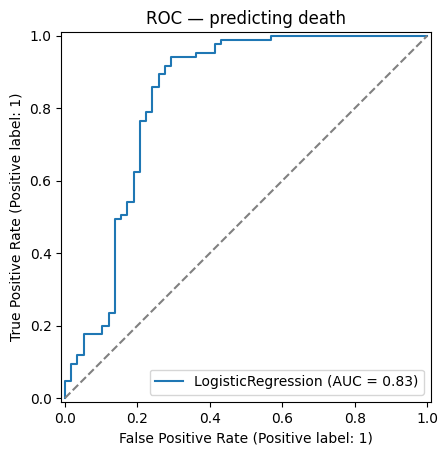

In [8]:
y_pred  = model1.predict(X_test)
y_proba = model1.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['Survived','Died']))

RocCurveDisplay.from_estimator(model1, X_test, y_test)
plt.plot([0,1],[0,1],'--',color='gray'); plt.title('ROC — predicting death'); plt.show()

Recall

Death prediction has asymmetric costs — a false negative (failing to flag someone who actually dies) is worse than a false positive (flagging someone who survives). Recall measures exactly that error: of the people who actually died, how many did we catch? Accuracy is the weakest choice here because a model that always predicts the majority class would score ~60% without being useful.

## #5 ##

No bc:
1. Linear regression's output is unbounded. It can predict probabilities below 0 or above 1, which is meaningless.
2. The errors for a binary outcome are Bernoulli, not Gaussian — OLS's assumptions are violated.
3. The true relationship between features and probability of death is S-shaped (saturating near 0 and 1), which is exactly what the logistic function models.

## Model 2 ##

## #1 ##

1. valence --> mood (positive tracks are more danceable)
2. energy --> physical intensity
3. loudness --> production style (dance/pop is mastered loud)

In [10]:
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score, mean_squared_error

SPOTIFY_CSV = 'spotify.csv' #this file doesn't exist
spotify = pd.read_csv(SPOTIFY_CSV)

feature_cols = ['valence', 'energy', 'loudness']
X = spotify[feature_cols].dropna()
y = spotify.loc[X.index, 'danceability']

X_scaled = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## #2 ##

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
grid_lasso = GridSearchCV(Lasso(max_iter=10000),
                          {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
                          cv=5, scoring='neg_mean_squared_error')
grid_lasso.fit(X_train, y_train)
best_lasso = grid_lasso.best_estimator_

print(f"Best Alpha: {grid_lasso.best_params_['alpha']}")
print(f"R^2:  {r2_score(y_test, best_lasso.predict(X_test)):.4f}")
print(f"Zeroed: {(best_lasso.coef_ == 0).sum()}/{len(best_lasso.coef_)}")

Best Alpha: 0.001
R^2:  -0.9309
Zeroed: 0/3


Around 0.001 or very small number. All three coefficients stay non-zero. This means all three features are pulling their weight — there's nothing for Lasso to feature-select away, so it picks minimal regularization and behaves like ordinary linear regression. Larger alphas would start zeroing useful coefficients, hurting CV score.

## #3 ##

In [12]:
from sklearn.model_selection import train_test_split, GridSearchCV
grid_ridge = GridSearchCV(Ridge(),
                          {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
                          cv=5, scoring='neg_mean_squared_error')
grid_ridge.fit(X_train, y_train)
best_ridge = grid_ridge.best_estimator_

print(f"Best Alpha: {grid_ridge.best_params_['alpha']}")
print(f"R^2:  {r2_score(y_test, best_ridge.predict(X_test)):.4f}")

Best Alpha: 10
R^2:  -0.8596


Around ≈ 0.1–10 (light shrinkage). Ridge never zeros coefficients — it just shrinks them. A small-to-moderate alpha says the unregularized estimates are already reasonable and only need a light touch. With 3 features and a large Spotify dataset, there's plenty of data per parameter, so heavy shrinkage isn't needed. Compare coefficients to Lasso's — they should be similar in sign and magnitude.

## W9 ##

## 1.
Unsupervised learning is when our data is explicitly labeled, and we ask the algorithm to learn something meaningful on its own without labels.

---

## 2. The 2 types of unsupervised learning we will explore today are: 

K-Means, principal component analysis (PCA)

---

## 3.What is a centroid? Take some time on this question after reading under the K-Means block in the ipynb. Draw some of your understanding out on the board! Include some formulas if you can.

A centroid is the geometric center of a data distribution or shape, or the average position of all data points within a cluster.

---

## 4.
Under line 7, the blue points represent data points and the stars represent centroids. 

---

## 5. Write the formula for finding the closest centroids on the board, and then summarize it using your own words here. 

To assign each data point to the nearest centroid by calculating the distance between the point and all centroids, then choosing the centroid with the smallest squared distance. The index of that closest centroid becomes the assignment for that point.

---

## 6. Read the code in line 8. Name the type of python object each of these are: 

centroids → NumPy array (typically a 2D array of centroid coordinates)

X → NumPy array (dataset of input points)

np.square → function (NumPy function for squaring values)

min_distance → float (stores the smallest distance found)

idx → int (index of the closest centroid)

---

## 7. What is the purpose of line 9? 

Checking if the function works

---

## 8. What is the difference between the first plot under line 7 versus the one in line 10? 

Line 7 = before assignment (just visualization)

Line 10 = after assignment (points are grouped by nearest centroid)

---

## 9. On the board, write the equation under 'Computing Centroid Means' and label each of the variables. On your canvas submission, write 2 sentences on what this equation represents. 

Calculates the new position of a centroid by taking the average of all data points assigned to that cluster. In K-Means, this step updates the centroid so it moves to the center of its cluster after each iteration.

## 10. What is the purpose of line 17-24? 

These lines tie everything together as runKMeans runs the two steps (findClosestCentroids and computeCentroids) in a loop for a fixed number of iterations and saves the centroid history so we can see them move. randomInitialization picks k random data points to use as starting centroids. The final loop runs k-means three separate times with different random starts to demonstrate that the algorithm's final clusters depend on where the centroids started.

---

## 11.

from sklearn.cluster import KMeans
km1 = KMeans(3)
km1.fit(X1)

---

## 12. Look up the parameters for Kmeans and explain them here! 

- n_clusters : number of clusters K
- init : how starting centroids are chosen --> k-means++ (default) spreads them out smartly, random picks them randomly.
- n_init : how many times to re-run with different random starts. Best result is kept
- max_iter : max iterations per run before stopping. Default 300
- tol : convergence tolerance; stop when centroids barely move
- random_state : seed for reproducibility
- algorithm : lloyd (classic) or elkan (faster on dense data)

---

## 13. Check out the image compression example from lines 27-36, and write at least 3 questions on the board that you have about it (if you don't have any questions, write 3 'takeaways'. 

1. Each pixel is treated as a 3D point in RGB space, so "clustering pixels" is the same algorithm as clustering anything else.
2. The compression comes from storage. Instead of 24 bits per pixel, you store one of 16 cluster indices plus the 16 RGB centers.
3. The compressed image looks close to the original because K-Means picks the 16 colors that minimize total distance to actual pixels.

---

## 14. It's PCA time. What type of object is X3 in line 39?

A NumPy array (shape (50, 2))
50 data points in 2 dimensions, loaded from data2['X']

---

## 15. What type of normalization are they doing for this data?

Standardization. Subtract the mean and divide by the standard deviation: X_norm = (X − μ) / σ. The result has mean 0 and standard deviation 1 in every dimension.

---

## 16. Vectors are kinda hard. Find a resource online to help you understand #3-- I'm here to help! Insert the resource here.

https://www.youtube.com/watch?v=PFDu9oVAE-g

---

## 17. In line 42, what is the purpose of this function, and what type of objects is the function returning?

Implements PCA from scratch in three steps normalize the data, compute the covariance matrix, and run SVD to extract eigenvectors. Returns six NumPy arrays: mean, std, X_norm, U (eigenvectors / principal components), S (singular values), and V.

---

## 18. Don't worry about all the particularities of line 47, data visualization is it's own class and specialty, but check out the graph. Read the paragraph just below and explain it in a sentence in normal-people speak here. I would ignore the paragraph after that unless you're feeling brave.

The data spreads out the most along the diagonal going from the lower-left to the upper-right, and that direction is the first principal component, the single axis that captures most of the variation. The shorter line perpendicular to it is the second principal component, capturing whatever variation is left.

---

## 19. Skip ahead to the graph under line 54. Write a sentence about what this is doing for me.

It shows each original 2D point being projected down onto a 1D line, with dashed lines connecting each original point to its new lower dimensional position.

---

## 20.

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X3)

---

## 21. In the code you just wrote above, where did X3 even come from? What is it? And what is n_components anyway?

X3 was created earlier in the notebook (line 39). It's the 50×2 toy dataset loaded from ex7data1.mat. n_components is the number of principal components to keep.

---

## 22. Somewhere before the graph are a few sentences that I would like you to comprehend:

(50, 2) is the shape of pca_result with 50 rows and 2 columns.
Variation per principal component [0.87062385 0.12937615] means the first principal component captures ~87% of the variance in the data, and the second captures ~13%. They add up to 100% because we kept all 2 components. If we had reduced to just 1 component, we'd have kept 87% of the variability and lost 13%.

---

## 24. Here's the fun now... Import the important libraries you need in a fresh ipynb, and run this code:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image
from sklearn.cluster import KMeans

china = load_sample_image("china.jpg")
print("Shape:", china.shape)   # (h, w, 3)

h, w, c = china.shape
X = china.reshape(-1, 3) / 255.0   # scale to [0,1]

n_colors = 16
km = KMeans(n_clusters=n_colors, n_init=10, random_state=42)
km.fit(X)

compressed = km.cluster_centers_[km.labels_].reshape(h, w, 3)